# Channel-Level EEG Prediction Of Familiarity

This notebook tests whether per-channel EEG band-power features can predict binary familiarity judgments (`responded`: familiar vs. not familiar) in the song familiarity task. The evaluation uses grouped cross-validation by participant so the reported metrics reflect generalization to unseen people rather than leakage across trials from the same subject.


## Pipeline Overview

1. Load the merged trial labels from `analysis/analysis_ready_familiarity_trials.csv`.
2. Read each subject's EEG recording from `ds005876/`, epoch the first 2 seconds after stimulus onset, and summarize each channel with delta, theta, alpha, and beta band power.
3. Compare participant-aware baselines and classifiers under grouped cross-validation, then inspect feature importance and univariate effect sizes for the strongest model.

This notebook is intentionally conservative: the main question is whether a simple channel-by-band representation carries enough signal to generalize across participants, not whether it can overfit idiosyncratic trials.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
}
EPOCH_TMIN = 0.0
EPOCH_TMAX = 2.0


def locate_project_root() -> Path:
    for candidate in [Path.cwd(), Path.cwd().parent]:
        if (candidate / "ds005876").exists() and (candidate / "analysis").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing ds005876 and analysis directories.")


ROOT = locate_project_root()
DATA_DIR = ROOT / "ds005876"
ANALYSIS_DIR = ROOT / "analysis"
PLOT_DIR = ROOT / "visuals" / "analysis_ready"
CACHE_PATH = ANALYSIS_DIR / "channel_band_power_trials.csv"
RESULTS_PATH = ANALYSIS_DIR / "channel_familiarity_model_results.csv"
IMPORTANCE_PATH = ANALYSIS_DIR / "channel_familiarity_feature_importance.csv"
EFFECTS_PATH = ANALYSIS_DIR / "channel_familiarity_univariate_effects.csv"
PLOT_PATH = PLOT_DIR / "channel_familiarity_prediction_summary.png"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {ROOT}")
print(f"Cache path: {CACHE_PATH}")


Project root: C:\Users\jnhdv\School Projects\COGS 189\COGS-189-Group-Project-WI26
Cache path: C:\Users\jnhdv\School Projects\COGS 189\COGS-189-Group-Project-WI26\analysis\channel_band_power_trials.csv


## 1. Extract Channel-Band Features

The next block resolves the project root, loads the analysis-ready trial table, and either reuses the cached feature matrix or rebuilds it directly from the BIDS EEG files. Each trial becomes a row with participant ID, trial metadata, and per-channel power estimates, which makes the later model comparison fully reproducible from saved CSVs.


In [2]:
def load_trial_metadata() -> pd.DataFrame:
    trial_path = ANALYSIS_DIR / "analysis_ready_familiarity_trials.csv"
    trial_df = pd.read_csv(trial_path)
    keep_cols = [
        "participant_id",
        "trial_index",
        "songFileName",
        "responded",
        "responded_label",
        "songDur",
        "note_rate",
    ]
    return trial_df[keep_cols].drop_duplicates(["participant_id", "trial_index"])


def extract_channel_band_power_features(use_cache: bool = True) -> pd.DataFrame:
    if use_cache and CACHE_PATH.exists():
        cached = pd.read_csv(CACHE_PATH)
        print(f"Loaded cached channel features: {cached.shape}")
        return cached

    frames = []
    for participant_id in sorted(path.name for path in DATA_DIR.glob("sub-*") if path.is_dir()):
        beh_path = DATA_DIR / participant_id / "beh" / f"{participant_id}_task-songfamiliarity_beh.tsv"
        eeg_path = DATA_DIR / participant_id / "eeg" / f"{participant_id}_task-songfamiliarity_eeg.set"
        events_path = DATA_DIR / participant_id / "eeg" / f"{participant_id}_task-songfamiliarity_events.tsv"
        if not (beh_path.exists() and eeg_path.exists() and events_path.exists()):
            continue

        behavior_df = pd.read_csv(beh_path, sep="\t")
        behavior_df["responded"] = pd.to_numeric(behavior_df["responded"], errors="coerce").fillna(0).astype(int)
        events_df = pd.read_csv(events_path, sep="\t")
        trial_starts = events_df[
            (events_df["value"].astype(str) == "1")
            & (events_df["stim_file"].astype(str) != "n/a")
        ].reset_index(drop=True)
        if trial_starts.empty:
            continue

        raw = mne.io.read_raw_eeglab(eeg_path, preload=True, verbose=False)
        eeg_picks = mne.pick_types(raw.info, eeg=True, exclude="bads")
        sfreq = raw.info["sfreq"]
        onsets = trial_starts["onset"].to_numpy(dtype=float)
        event_array = np.column_stack([
            (onsets * sfreq).astype(int),
            np.zeros(len(onsets), dtype=int),
            np.ones(len(onsets), dtype=int),
        ])
        epochs = mne.Epochs(
            raw,
            event_array,
            event_id={"trial": 1},
            tmin=EPOCH_TMIN,
            tmax=EPOCH_TMAX,
            baseline=None,
            picks=eeg_picks,
            preload=True,
            on_missing="ignore",
            verbose=False,
        )
        spectrum = epochs.compute_psd(method="welch", fmin=1, fmax=30, verbose=False)
        psds, freqs = spectrum.get_data(return_freqs=True)
        ch_names = [raw.ch_names[idx] for idx in eeg_picks]
        n_trials = min(len(behavior_df), psds.shape[0])

        rows = []
        for trial_index in range(n_trials):
            row = {
                "participant_id": participant_id,
                "trial_index": trial_index,
                "responded": int(behavior_df.loc[trial_index, "responded"]),
            }
            trial_psd = psds[trial_index]
            for band_name, (low_hz, high_hz) in BANDS.items():
                band_mask = (freqs >= low_hz) & (freqs < high_hz)
                band_values = []
                for channel_index, channel_name in enumerate(ch_names):
                    value = float(np.log10(trial_psd[channel_index][band_mask].mean() + 1e-20))
                    row[f"{channel_name}_{band_name}"] = value
                    band_values.append(value)
                row[f"global_{band_name}"] = float(np.mean(band_values))
            rows.append(row)

        participant_df = pd.DataFrame(rows)
        frames.append(participant_df)
        print(f"Extracted {participant_id}: {participant_df.shape[0]} trials, {len(ch_names)} channels")

    channel_df = pd.concat(frames, ignore_index=True)
    channel_df.to_csv(CACHE_PATH, index=False)
    print(f"Saved channel feature cache to {CACHE_PATH}")
    return channel_df


def participant_center(df: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    centered = df.copy()
    centered[feature_cols] = centered.groupby("participant_id")[feature_cols].transform(
        lambda col: (col - col.mean()) / (col.std(ddof=0) + 1e-6)
    )
    return centered


trial_meta = load_trial_metadata()
channel_df = extract_channel_band_power_features(use_cache=True)
analysis_df = channel_df.merge(
    trial_meta,
    on=["participant_id", "trial_index", "responded"],
    how="left",
)
display(
    pd.DataFrame(
        {
            "table": ["channel_df", "analysis_df"],
            "rows": [len(channel_df), len(analysis_df)],
            "columns": [channel_df.shape[1], analysis_df.shape[1]],
        }
    )
)
display(analysis_df.head())


Loaded cached channel features: (2074, 135)


,table,rows,columns
0,channel_df,2074,135
1,analysis_df,2074,139


,participant_id,trial_index,responded,Fp1_delta,F3_delta,F7_delta,FC5_delta,FC1_delta,FCz_delta,C3_delta,...,FC2_beta,F4_beta,F8_beta,AFz_beta,Fp2_beta,global_beta,songFileName,responded_label,songDur,note_rate
0,sub-01,0,0,-9.908214,-12.673464,-12.134449,-11.618016,-11.771633,-11.593911,-11.268586,...,-13.578099,-13.366865,-13.023408,-13.305132,-12.916501,-12.969335,do wah ditty.wav,Not familiar,7.758005,1.345483
1,sub-01,1,1,-10.252528,-12.906555,-11.687822,-12.165787,-11.830351,-11.789063,-11.583532,...,-13.487564,-13.556936,-13.076228,-13.268125,-13.168117,-13.052164,alouette.wav,Familiar,5.946984,0.986547
2,sub-01,2,1,-9.963553,-12.270893,-11.528371,-11.691843,-11.555175,-11.420433,-11.197699,...,-13.366726,-13.186518,-13.139799,-13.357394,-12.884950,-12.990811,great escape.wav,Familiar,15.750023,1.689532
3,sub-01,3,1,-12.416171,-12.434184,-12.256560,-12.143033,-12.375432,-12.870304,-12.259601,...,-13.418293,-13.407639,-13.232246,-13.490654,-13.267965,-13.148372,buffalo gals.wav,Familiar,9.331020,0.971860
4,sub-01,4,0,-12.429921,-12.764644,-12.061389,-12.174439,-12.725883,-12.698564,-12.558629,...,-13.417494,-13.550835,-13.210312,-13.415066,-13.374063,-13.157153,over the river and through the woods.wav,Not familiar,13.913016,2.294688


## 2. Compare Participant-Aware Models

These models are fit with grouped folds so the same participant never appears in both train and validation data. That matters here because trial-level EEG features are strongly clustered within person; ordinary random CV would overstate performance.


In [3]:
channel_cols = [
    col
    for col in analysis_df.columns
    if any(col.endswith(f"_{band_name}") for band_name in BANDS)
    and not col.startswith("global_")
]
global_cols = [col for col in analysis_df.columns if col.startswith("global_")]
centered_df = participant_center(analysis_df, channel_cols + global_cols)

X_sets = {
    "dummy_channel": analysis_df[channel_cols],
    "global_logreg": analysis_df[global_cols],
    "channel_logreg": analysis_df[channel_cols],
    "channel_centered_logreg": centered_df[channel_cols],
    "channel_centered_pca_logreg": centered_df[channel_cols],
    "channel_centered_rf": centered_df[channel_cols],
}
models = {
    "dummy_channel": DummyClassifier(strategy="prior"),
    "global_logreg": Pipeline(
        [
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
            ("clf", LogisticRegression(max_iter=4000, class_weight="balanced", C=0.1)),
        ]
    ),
    "channel_logreg": Pipeline(
        [
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
            ("clf", LogisticRegression(max_iter=4000, class_weight="balanced", C=0.1)),
        ]
    ),
    "channel_centered_logreg": Pipeline(
        [
            ("impute", SimpleImputer(strategy="median")),
            ("clf", LogisticRegression(max_iter=4000, class_weight="balanced", C=0.1)),
        ]
    ),
    "channel_centered_pca_logreg": Pipeline(
        [
            ("impute", SimpleImputer(strategy="median")),
            ("pca", PCA(n_components=0.9, svd_solver="full")),
            ("clf", LogisticRegression(max_iter=4000, class_weight="balanced", C=1.0)),
        ]
    ),
    "channel_centered_rf": RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=1,
        class_weight="balanced_subsample",
    ),
}

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy",
    "accuracy": "accuracy",
    "f1": "f1",
}
y = analysis_df["responded"]
groups = analysis_df["participant_id"]

rows = []
for model_name, estimator in models.items():
    scores = cross_validate(
        estimator,
        X_sets[model_name],
        y,
        groups=groups,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
    )
    row = {"model": model_name}
    for metric_name in scoring:
        metric_values = scores[f"test_{metric_name}"]
        row[f"{metric_name}_mean"] = metric_values.mean()
        row[f"{metric_name}_std"] = metric_values.std()
    rows.append(row)

results_df = pd.DataFrame(rows).sort_values("roc_auc_mean", ascending=False).reset_index(drop=True)
results_df.to_csv(RESULTS_PATH, index=False)
display(results_df)
best_row = results_df.iloc[0]
print(
    f"Best grouped ROC AUC: {best_row['roc_auc_mean']:.3f} +/- {best_row['roc_auc_std']:.3f} "
    f"with {best_row['model']}"
)


,model,roc_auc_mean,roc_auc_std,balanced_accuracy_mean,balanced_accuracy_std,accuracy_mean,accuracy_std,f1_mean,f1_std
0,channel_centered_rf,0.520720,0.020827,0.514486,0.020211,0.509857,0.021114,0.497174,0.021706
1,dummy_channel,0.500000,0.000000,0.500000,0.000000,0.463335,0.030304,0.248925,0.305349
2,channel_centered_pca_logreg,0.499376,0.016108,0.496646,0.013678,0.496769,0.013100,0.495738,0.038262
3,channel_centered_logreg,0.467146,0.011346,0.481337,0.010016,0.481398,0.010054,0.487087,0.029229
4,channel_logreg,0.458730,0.091395,0.465434,0.065300,0.459432,0.058860,0.455609,0.091344
5,global_logreg,0.437880,0.061095,0.443959,0.046124,0.434750,0.037382,0.402967,0.108186


Best grouped ROC AUC: 0.521 +/- 0.021 with channel_centered_rf


## 3. Inspect The Best Feature Set

After ranking the candidate models, the notebook computes out-of-fold probabilities for the winner and then asks a second question: where is the weak predictive signal concentrated? Random-forest importances and simple effect sizes answer that descriptively, even when the overall classification result stays close to chance.


In [4]:
best_model_name = results_df.loc[0, "model"]
best_model = models[best_model_name]
best_X = X_sets[best_model_name]
out_of_fold_prob = cross_val_predict(
    best_model,
    best_X,
    y,
    groups=groups,
    cv=cv,
    method="predict_proba",
    n_jobs=1,
)[:, 1]
print(f"Out-of-fold ROC AUC for {best_model_name}: {roc_auc_score(y, out_of_fold_prob):.3f}")

rf_importance_model = clone(models["channel_centered_rf"])
rf_importance_model.fit(centered_df[channel_cols], y)
importance_df = pd.DataFrame(
    {
        "feature": channel_cols,
        "importance": rf_importance_model.feature_importances_,
    }
)
importance_df["channel"] = importance_df["feature"].str.split("_").str[0]
importance_df["band"] = importance_df["feature"].str.split("_").str[1]
importance_df = importance_df.sort_values("importance", ascending=False).reset_index(drop=True)
importance_df.to_csv(IMPORTANCE_PATH, index=False)

effect_rows = []
for feature_name in channel_cols:
    familiar_values = centered_df.loc[y == 1, feature_name]
    unfamiliar_values = centered_df.loc[y == 0, feature_name]
    pooled_sd = np.sqrt((familiar_values.var(ddof=1) + unfamiliar_values.var(ddof=1)) / 2)
    cohens_d = 0.0 if pooled_sd == 0 else (familiar_values.mean() - unfamiliar_values.mean()) / pooled_sd
    channel_name, band_name = feature_name.split("_", 1)
    effect_rows.append(
        {
            "feature": feature_name,
            "channel": channel_name,
            "band": band_name,
            "cohens_d": cohens_d,
            "abs_d": abs(cohens_d),
        }
    )
effects_df = pd.DataFrame(effect_rows).sort_values("abs_d", ascending=False).reset_index(drop=True)
effects_df.to_csv(EFFECTS_PATH, index=False)

display(importance_df.head(15))
display(effects_df.head(15))


Out-of-fold ROC AUC for channel_centered_rf: 0.513


,feature,importance,channel,band
0,FC6_delta,0.010549,FC6,delta
1,Cz_alpha,0.010142,Cz,alpha
2,F4_theta,0.009870,F4,theta
3,T8_alpha,0.009815,T8,alpha
4,T7_theta,0.009583,T7,theta
5,TP9_beta,0.009574,TP9,beta
6,CP5_theta,0.009535,CP5,theta
7,TP10_alpha,0.009333,TP10,alpha
8,Pz_alpha,0.009281,Pz,alpha
9,F7_beta,0.009278,F7,beta


,feature,channel,band,cohens_d,abs_d
0,T7_theta,T7,theta,0.094840,0.094840
1,O1_beta,O1,beta,-0.081617,0.081617
2,FC5_theta,FC5,theta,0.079795,0.079795
3,F4_beta,F4,beta,-0.078003,0.078003
4,Oz_alpha,Oz,alpha,-0.076533,0.076533
5,TP9_beta,TP9,beta,-0.076156,0.076156
6,P7_beta,P7,beta,-0.071432,0.071432
7,FC6_delta,FC6,delta,0.071350,0.071350
8,F7_beta,F7,beta,-0.069913,0.069913
9,T8_theta,T8,theta,0.062146,0.062146


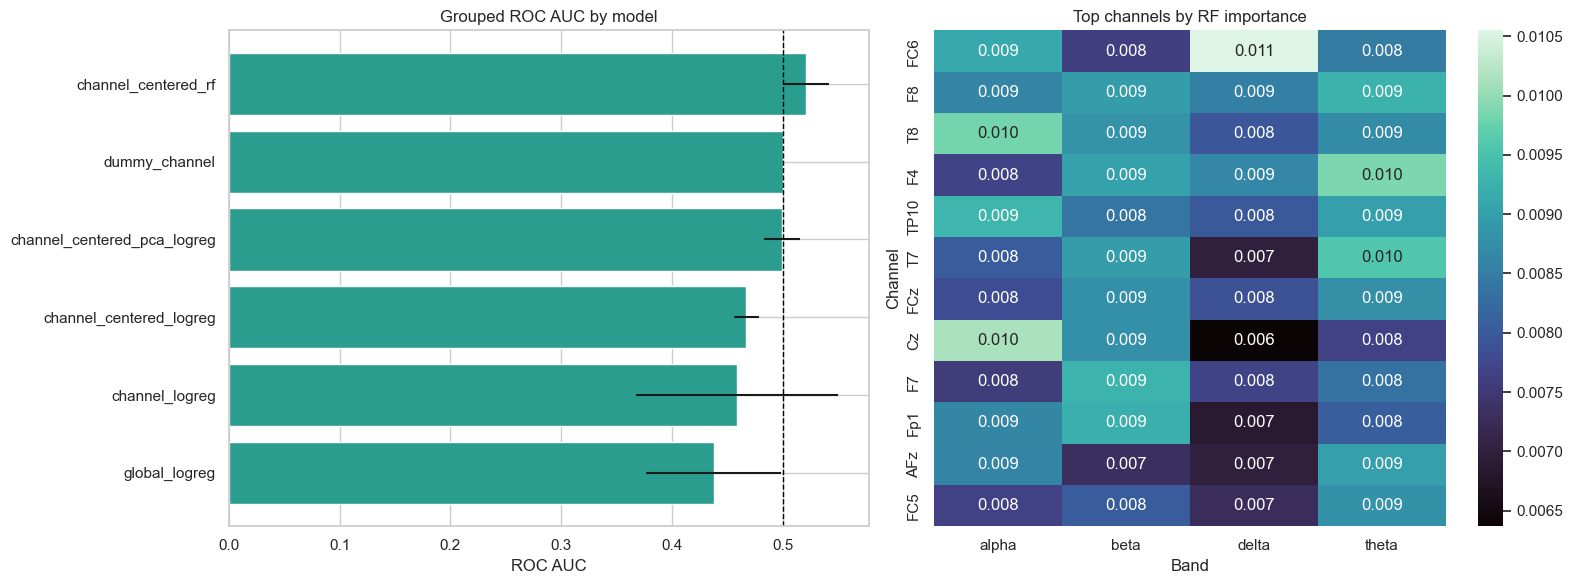

Mean RF importance by band:


,mean_importance
band,
beta,0.008131
alpha,0.008015
theta,0.007881
delta,0.007224


Saved summary plot to C:\Users\jnhdv\School Projects\COGS 189\COGS-189-Group-Project-WI26\visuals\analysis_ready\channel_familiarity_prediction_summary.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_results = results_df.sort_values("roc_auc_mean", ascending=True)
axes[0].barh(plot_results["model"], plot_results["roc_auc_mean"], xerr=plot_results["roc_auc_std"], color="#2A9D8F")
axes[0].axvline(0.5, linestyle="--", color="black", linewidth=1)
axes[0].set_title("Grouped ROC AUC by model")
axes[0].set_xlabel("ROC AUC")

top_channels = (
    importance_df.groupby("channel")["importance"]
    .mean()
    .sort_values(ascending=False)
    .head(12)
    .index
)
heatmap_df = (
    importance_df[importance_df["channel"].isin(top_channels)]
    .pivot_table(index="channel", columns="band", values="importance", aggfunc="mean")
    .loc[top_channels]
)
sns.heatmap(heatmap_df, cmap="mako", annot=True, fmt=".3f", ax=axes[1])
axes[1].set_title("Top channels by RF importance")
axes[1].set_xlabel("Band")
axes[1].set_ylabel("Channel")

plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=200, bbox_inches="tight")
plt.show()

band_summary = importance_df.groupby("band")["importance"].mean().sort_values(ascending=False)
print("Mean RF importance by band:")
display(band_summary.to_frame("mean_importance"))
print(f"Saved summary plot to {PLOT_PATH}")


## Result Notes

The best grouped model is the participant-centered random forest with `ROC AUC = 0.521 +/- 0.021`, and its out-of-fold ROC AUC is `0.513`. That is only a marginal lift over the dummy baseline, so this feature representation should be read as weakly predictive at best.

The importance table spreads its weight across many channels and bands rather than isolating one clean locus. Beta and alpha contribute slightly more on average than delta, but the leading features are distributed across frontal, central, and temporal channels, and the largest univariate effects are all very small (`|d| < 0.10`). The practical interpretation is that simple channel-level band power does not provide a robust cross-subject familiarity marker in this dataset.


## Takeaway

The grouped evaluation is the important result here. If the best model stays close to `ROC AUC = 0.50`, channel-level EEG band power is not reliably predicting familiarity for unseen participants in this dataset. The feature-importance and effect-size tables still help identify where the weak signal is concentrated, but the modeling result should be interpreted as near-chance unless a materially stronger held-out score appears.
